# HANDWRITTEN DIGIT RECOGNITION SYSTEM
### Implementation 1 - Initial Image Classification System
### Department of Computing, Rajarata University of Sri Lanka
### Course: ICT 3212 - Introduction to Intelligent Systems

## Environment Setup and Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow/Keras imports
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

2026-02-26 16:39:29.434652: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 16:39:29.549731: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 16:39:32.505571: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Dataset Loading and Exploration

In [2]:
print("LOADING MNIST DATASET \n")

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Original training data shape: {x_train.shape}")

x_train = x_train[:6000]
y_train = y_train[:6000]

print(f"Reduced training data shape: {x_train.shape}")
print(f"Reduced training labels shape: {y_train.shape}")

print(f"Testing data shape: {x_test.shape}")
print(f"Image dimensions: {x_train.shape[1]} x {x_train.shape[2]} pixels")
print(f"Pixel value range: {x_train.min()} to {x_train.max()}")

LOADING MNIST DATASET 

Original training data shape: (60000, 28, 28)
Reduced training data shape: (6000, 28, 28)
Reduced training labels shape: (6000,)
Testing data shape: (10000, 28, 28)
Image dimensions: 28 x 28 pixels
Pixel value range: 0 to 255


## Dataset Visualization

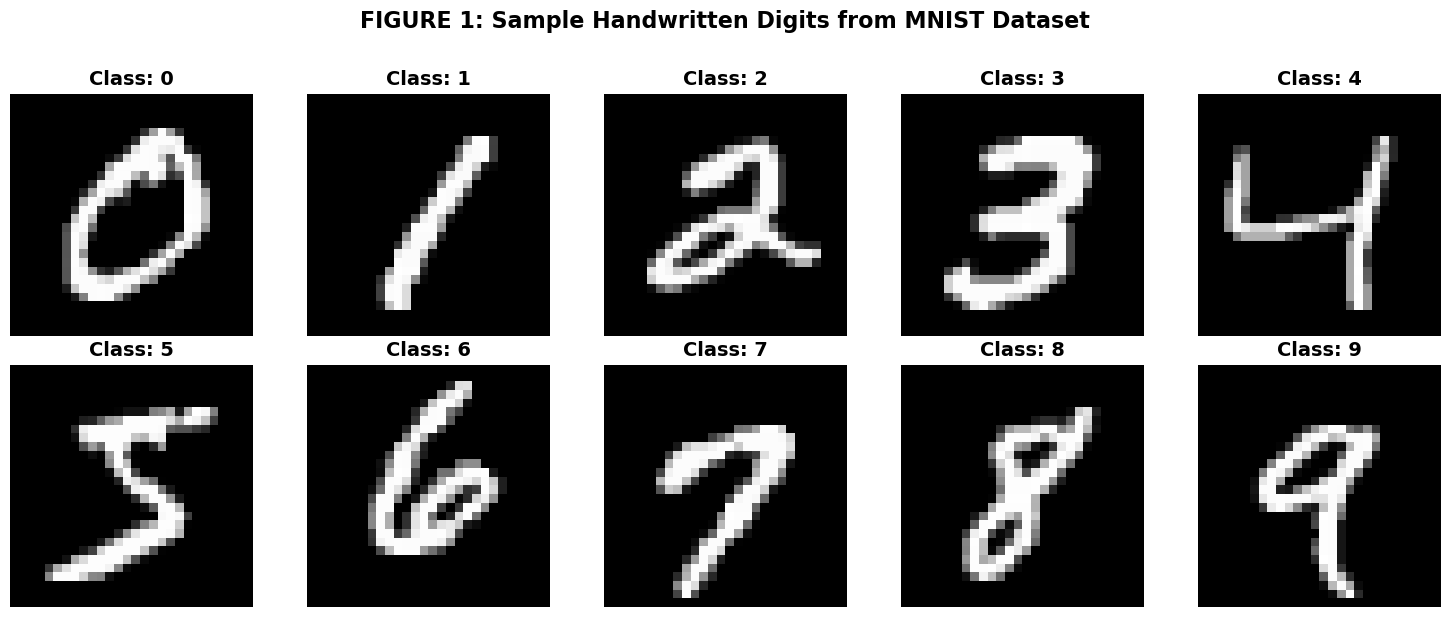

In [3]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Find the first occurrence of each digit
    indices = np.where(y_train == i)[0]
    first_idx = indices[0]
    
    axes[i].imshow(x_train[first_idx], cmap='gray')
    axes[i].set_title(f'Class: {i}', fontsize=14, fontweight='bold')
    axes[i].axis('off')
    axes[i].grid(False)

plt.suptitle('FIGURE 1: Sample Handwritten Digits from MNIST Dataset', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_digits.png', dpi=300, bbox_inches='tight')
plt.show()

## Dataset Balance Verification

In [4]:
# Calculate class distribution
train_classes, train_counts = np.unique(y_train, return_counts=True)
test_classes, test_counts = np.unique(y_test, return_counts=True)

print("DATASET BALANCE VERIFICATION \n")
print("\n TRAINING SET DISTRIBUTION: \n")
for digit, count in zip(train_classes, train_counts):
    percentage = (count / len(y_train)) * 100
    print(f"   Digit {digit}: {count:5d} samples ({percentage:.2f}%)")

print("\n TESTING SET DISTRIBUTION: \n")
for digit, count in zip(test_classes, test_counts):
    percentage = (count / len(y_test)) * 100
    print(f"   Digit {digit}: {count:5d} samples ({percentage:.2f}%)")



DATASET BALANCE VERIFICATION 


 TRAINING SET DISTRIBUTION: 

   Digit 0:   592 samples (9.87%)
   Digit 1:   671 samples (11.18%)
   Digit 2:   581 samples (9.68%)
   Digit 3:   608 samples (10.13%)
   Digit 4:   623 samples (10.38%)
   Digit 5:   514 samples (8.57%)
   Digit 6:   608 samples (10.13%)
   Digit 7:   651 samples (10.85%)
   Digit 8:   551 samples (9.18%)
   Digit 9:   601 samples (10.02%)

 TESTING SET DISTRIBUTION: 

   Digit 0:   980 samples (9.80%)
   Digit 1:  1135 samples (11.35%)
   Digit 2:  1032 samples (10.32%)
   Digit 3:  1010 samples (10.10%)
   Digit 4:   982 samples (9.82%)
   Digit 5:   892 samples (8.92%)
   Digit 6:   958 samples (9.58%)
   Digit 7:  1028 samples (10.28%)
   Digit 8:   974 samples (9.74%)
   Digit 9:  1009 samples (10.09%)


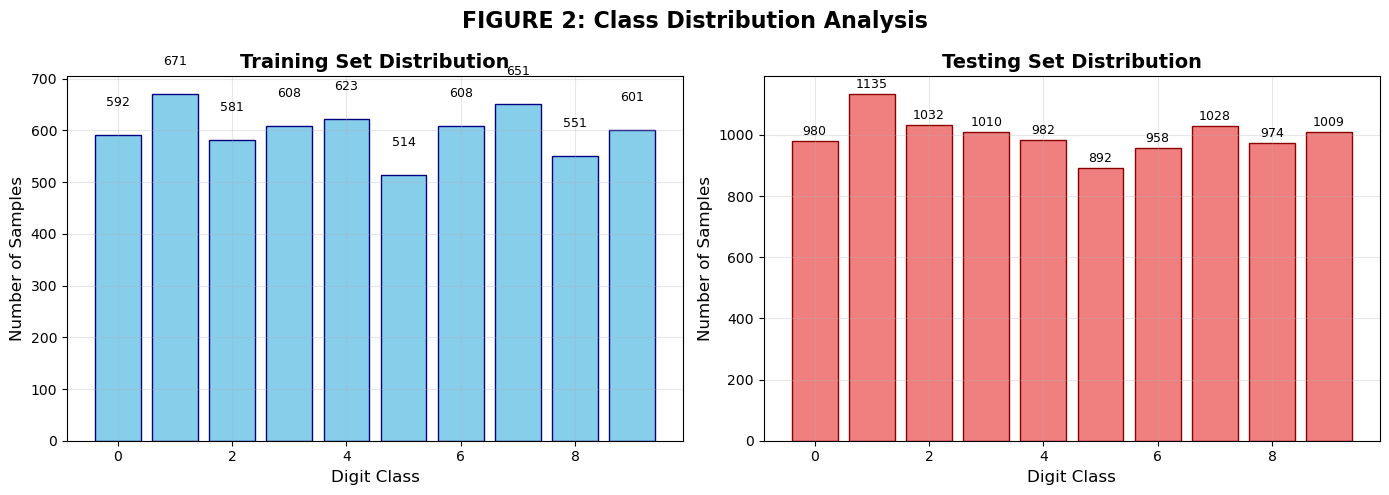

In [5]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training distribution
bars1 = axes[0].bar(train_classes, train_counts, color='skyblue', edgecolor='navy')
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Digit Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].grid(True, alpha=0.3)
for bar, count in zip(bars1, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count}', ha='center', va='bottom', fontsize=9)

# Testing distribution
bars2 = axes[1].bar(test_classes, test_counts, color='lightcoral', edgecolor='darkred')
axes[1].set_title('Testing Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Digit Class', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].grid(True, alpha=0.3)
for bar, count in zip(bars2, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{count}', ha='center', va='bottom', fontsize=9)

plt.suptitle('FIGURE 2: Class Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Image Preprocessing

In [6]:
print("IMAGE PREPROCESSING STEPS")

x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0
x_train_reshaped = x_train_normalized.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_normalized.reshape(-1, 28, 28, 1)
y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)



IMAGE PREPROCESSING STEPS


## CNN Model Architecture Design

In [7]:
print("CNN MODEL ARCHITECTURE \n")

# Initialize Sequential model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                 input_shape=(28, 28, 1), name='conv2d_1'))
model.add(MaxPooling2D(pool_size=(2, 2), name='maxpool_1'))
model.add(Dropout(0.25, name='dropout_1'))   # NEW Dropout
print(" Layer 1: Conv2D (32 filters, 3x3) + MaxPooling (2x2) + Dropout (0.25)")

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv2d_2'))
model.add(MaxPooling2D(pool_size=(2, 2), name='maxpool_2'))
model.add(Dropout(0.5, name='dropout_2'))   # NEW Dropout
print(" Layer 2: Conv2D (64 filters, 3x3) + MaxPooling (2x2) + Dropout (0.25)")

model.add(Flatten(name='flatten'))
print(" Layer 3: Flatten layer")

model.add(Dense(128, activation='relu', name='dense_128'))
model.add(Dropout(0.5, name='dropout_3'))   # Strong regularization
print(" Layer 4: Dense (128 units) + Dropout (0.5)")

model.add(Dense(10, activation='softmax', name='output_layer'))
print(" Layer 5: Output layer (10 units, softmax)")

print("MODEL SUMMARY \n")
model.summary()

# Parameter count
total_params = model.count_params()
trainable_params = sum([w.shape.num_elements() for w in model.trainable_weights])

print(f"\n PARAMETER COUNT:")
print(f"   - Total parameters: {total_params:,}")
print(f"   - Trainable parameters: {trainable_params:,}")
print(f"   - Non-trainable parameters: {total_params - trainable_params:,}")

CNN MODEL ARCHITECTURE 

 Layer 1: Conv2D (32 filters, 3x3) + MaxPooling (2x2) + Dropout (0.25)
 Layer 2: Conv2D (64 filters, 3x3) + MaxPooling (2x2) + Dropout (0.25)
 Layer 3: Flatten layer
 Layer 4: Dense (128 units) + Dropout (0.5)
 Layer 5: Output layer (10 units, softmax)
MODEL SUMMARY 



/home/ridhurshan/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-26 16:39:35.034226: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


 PARAMETER COUNT:
   - Total parameters: 225,034
   - Trainable parameters: 225,034
   - Non-trainable parameters: 0


## Model Compilation

In [8]:
print("MODEL COMPILATION \n")

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ptimizer: Adam")
print("Loss Function: Categorical Crossentropy")
print("Metrics: Accuracy")
print("\n COMPILATION CONFIGURATION:")
print("   - Learning rate: Default (0.001)")
print("   - Beta_1: 0.9, Beta_2: 0.999")
print("   - Epsilon: 1e-07")

MODEL COMPILATION 

ptimizer: Adam
Loss Function: Categorical Crossentropy
Metrics: Accuracy

 COMPILATION CONFIGURATION:
   - Learning rate: Default (0.001)
   - Beta_1: 0.9, Beta_2: 0.999
   - Epsilon: 1e-07


## Model Training

In [9]:
print("MODEL TRAINING \n")
print(f"Training configuration:")
print(f"   - Epochs: 10")
print(f"   - Batch size: 80")
print(f"   - Validation split: 10%")
print(f"   - Training samples: {x_train_reshaped.shape[0]}")
print(f"   - Validation samples: {int(0.1 * x_train_reshaped.shape[0])}")
print("\n")

# Train the model
history = model.fit(
    x_train_reshaped, y_train_categorical,
    epochs=10,
    batch_size=80,
    validation_split=0.1,
    verbose=1
)

print("\n Training completed successfully! \n")

MODEL TRAINING 

Training configuration:
   - Epochs: 10
   - Batch size: 80
   - Validation split: 10%
   - Training samples: 6000
   - Validation samples: 600


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5474 - loss: 1.3628 - val_accuracy: 0.8950 - val_loss: 0.4001
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8433 - loss: 0.5047 - val_accuracy: 0.9333 - val_loss: 0.2207
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9039 - loss: 0.3284 - val_accuracy: 0.9483 - val_loss: 0.1753
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9180 - loss: 0.2673 - val_accuracy: 0.9533 - val_loss: 0.1475
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9389 - loss: 0.2073 - val_accuracy: 0.9650 - val_loss: 0.1224
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9411 - loss: 0.1939 - val_accuracy: 0.9683 - val_loss: 0.1154
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9485 - los

## Training Performance Analysis

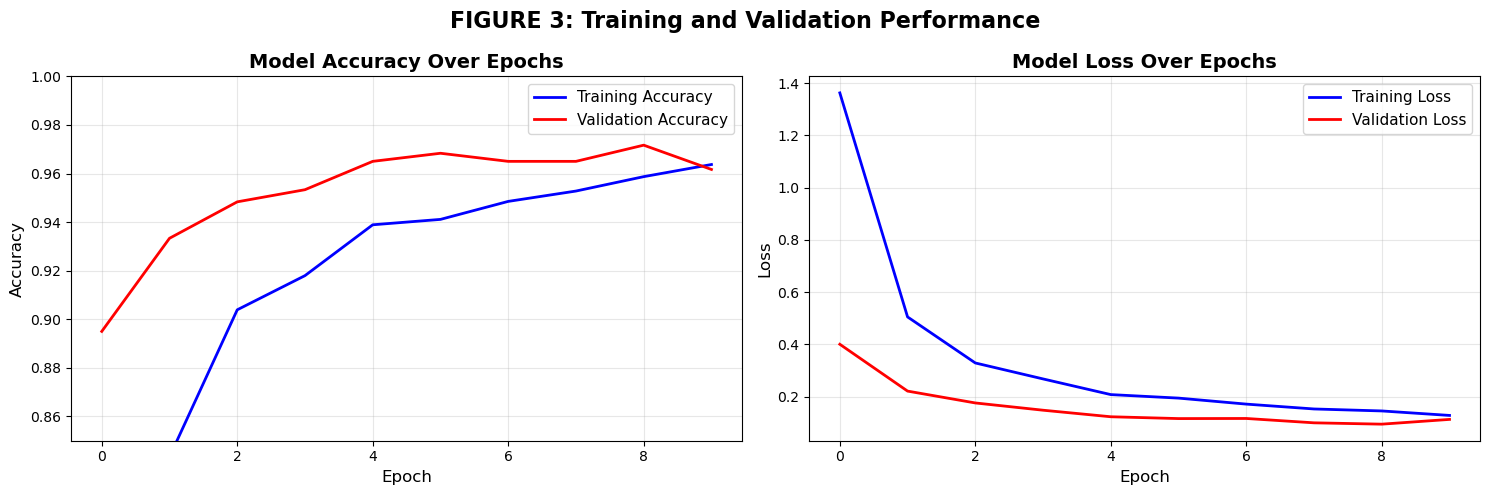


 FINAL EPOCH PERFORMANCE: 

   - Training Accuracy: 0.9637 (96.37%)
   - Validation Accuracy: 0.9617 (96.17%)
   - Training Loss: 0.1275
   - Validation Loss: 0.1123


In [10]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], 'b-', linewidth=2, label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.85, 1.0])

# Loss plot
axes[1].plot(history.history['loss'], 'b-', linewidth=2, label='Training Loss')
axes[1].plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('FIGURE 3: Training and Validation Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Display final epoch results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n FINAL EPOCH PERFORMANCE: \n")
print(f"   - Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"   - Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"   - Training Loss: {final_train_loss:.4f}")
print(f"   - Validation Loss: {final_val_loss:.4f}")

## Model Evaluation on Test Set

In [11]:
print("MODEL EVALUATION ON TEST SET \n")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test_reshaped, y_test_categorical, verbose=0)

print(f"\n TEST SET PERFORMANCE:")
print(f"   - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - Test Loss: {test_loss:.4f}")

# Generate predictions for detailed analysis
y_pred = model.predict(x_test_reshaped, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

MODEL EVALUATION ON TEST SET 


 TEST SET PERFORMANCE:
   - Test Accuracy: 0.9737 (97.37%)
   - Test Loss: 0.0806


## Confusion Matrix Analysis

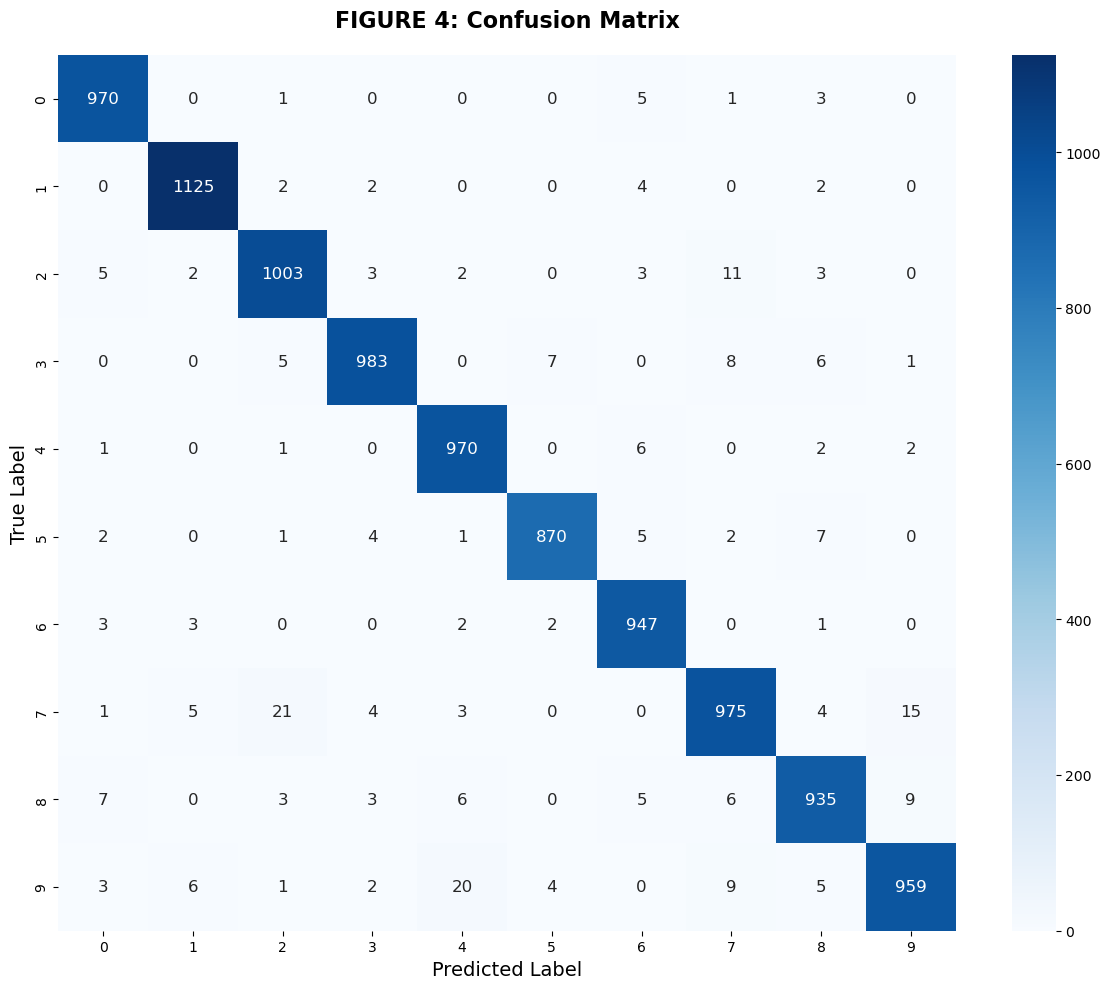


📋 CLASSIFICATION REPORT: 

              precision    recall  f1-score   support

     Digit 0       0.98      0.99      0.98       980
     Digit 1       0.99      0.99      0.99      1135
     Digit 2       0.97      0.97      0.97      1032
     Digit 3       0.98      0.97      0.98      1010
     Digit 4       0.97      0.99      0.98       982
     Digit 5       0.99      0.98      0.98       892
     Digit 6       0.97      0.99      0.98       958
     Digit 7       0.96      0.95      0.96      1028
     Digit 8       0.97      0.96      0.96       974
     Digit 9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [12]:
# Create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            annot_kws={'size': 12})
plt.title('FIGURE 4: Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print classification report
print("\n📋 CLASSIFICATION REPORT: \n")
print(classification_report(y_true_classes, y_pred_classes, 
                           target_names=[f'Digit {i}' for i in range(10)]))

## Sample Predictions Visualization

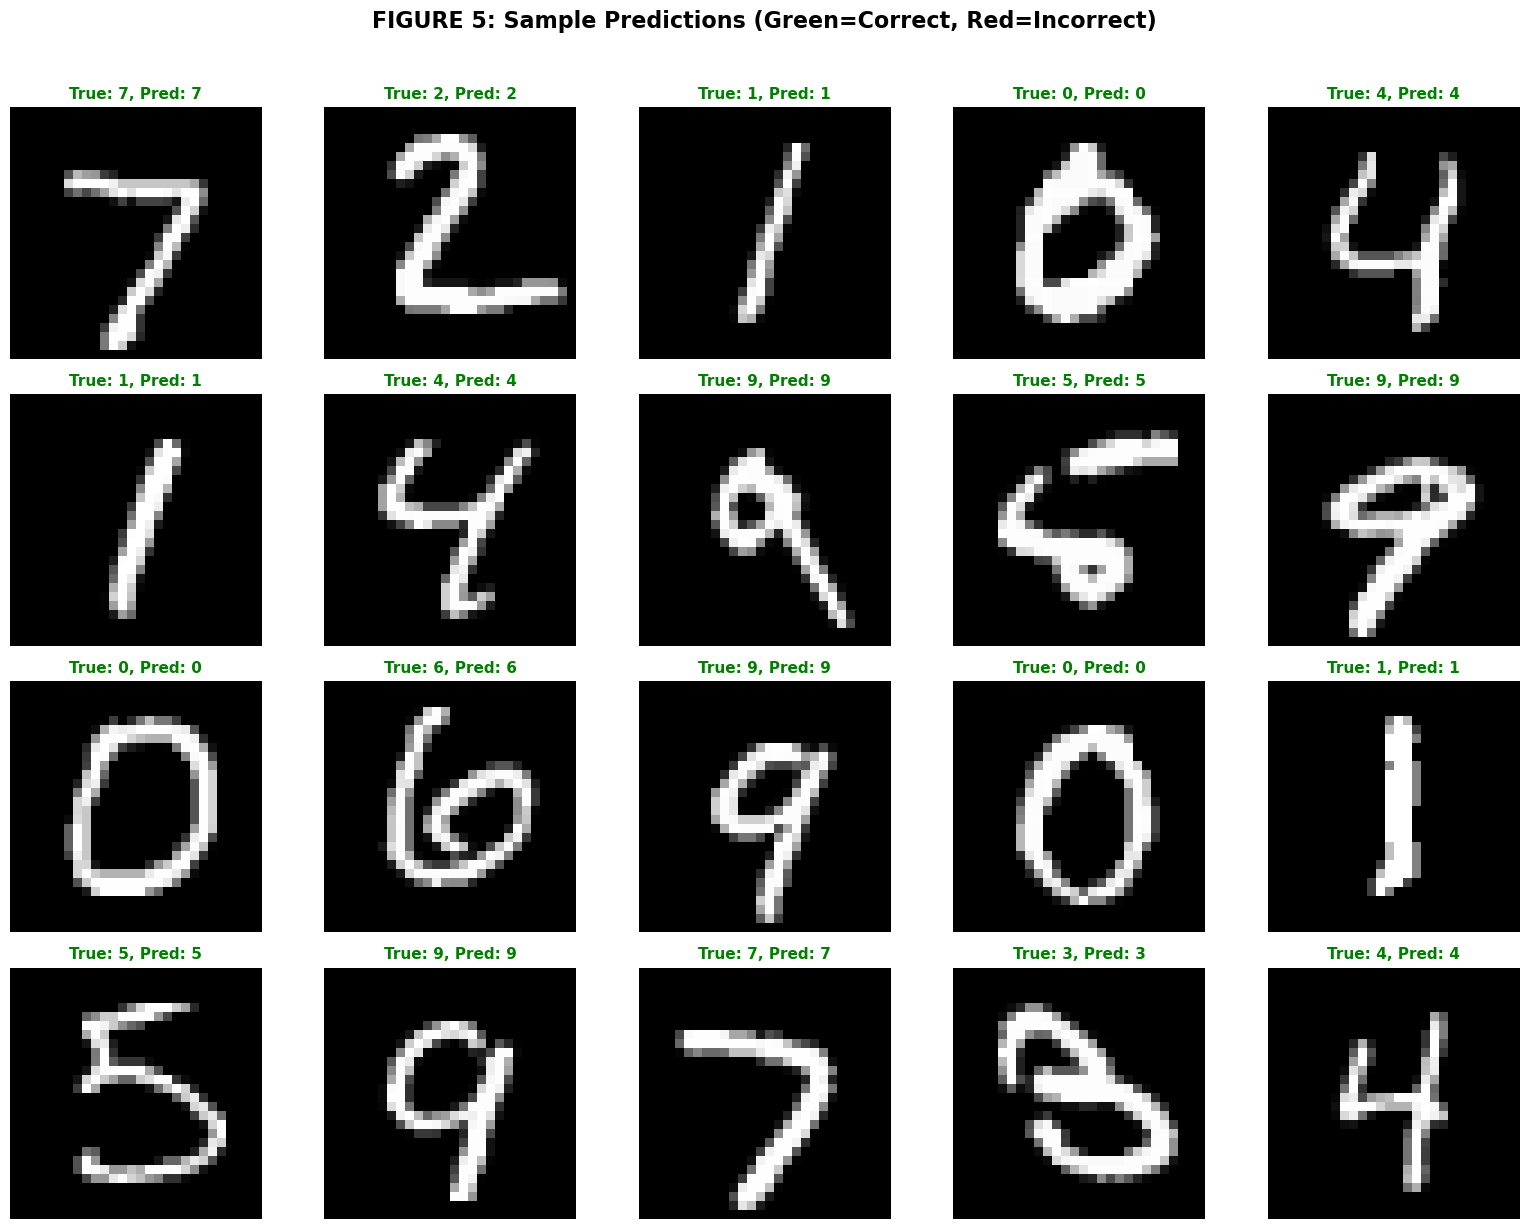


📊 Sample Statistics: 20/20 correct (100%)


In [13]:
# Show sample predictions
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.ravel()

for i in range(20):
    axes[i].imshow(x_test_reshaped[i].reshape(28, 28), cmap='gray')
    true_label = y_true_classes[i]
    pred_label = y_pred_classes[i]
    
    # Color code: green for correct, red for incorrect
    color = 'green' if true_label == pred_label else 'red'
    
    axes[i].set_title(f'True: {true_label}, Pred: {pred_label}', 
                     color=color, fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('FIGURE 5: Sample Predictions (Green=Correct, Red=Incorrect)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate accuracy on these samples
correct_count = sum(1 for i in range(20) if y_true_classes[i] == y_pred_classes[i])
print(f"\n📊 Sample Statistics: {correct_count}/20 correct ({correct_count*5}%)")

## Error Analysis

ERROR ANALYSIS 


 Total misclassified images: 263 out of 10000
 Overall Accuracy: 97.37%


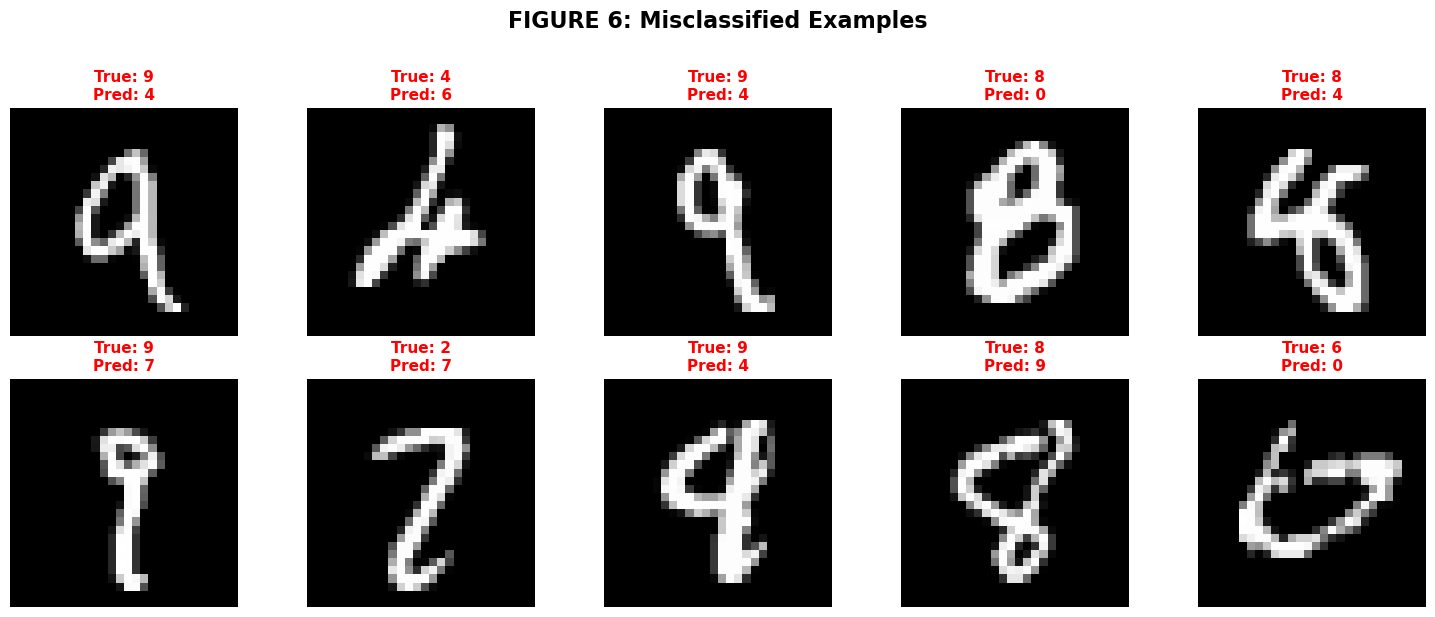


 MISCLASSIFICATION PATTERNS: 

   Digit 0: Most often confused with 6 (5 times)
   Digit 1: Most often confused with 6 (4 times)
   Digit 2: Most often confused with 7 (11 times)
   Digit 3: Most often confused with 7 (8 times)
   Digit 4: Most often confused with 6 (6 times)
   Digit 5: Most often confused with 8 (7 times)
   Digit 6: Most often confused with 0 (3 times)
   Digit 7: Most often confused with 2 (21 times)
   Digit 8: Most often confused with 9 (9 times)
   Digit 9: Most often confused with 4 (20 times)


In [14]:
# Find misclassified examples
misclassified_indices = np.where(y_true_classes != y_pred_classes)[0]
misclassified_count = len(misclassified_indices)

print("ERROR ANALYSIS \n")
print(f"\n Total misclassified images: {misclassified_count} out of {len(y_true_classes)}")
print(f" Overall Accuracy: {(1 - misclassified_count/len(y_true_classes))*100:.2f}%")

# Display misclassified examples
if misclassified_count > 0:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    display_count = min(10, misclassified_count)
    for i in range(display_count):
        idx = misclassified_indices[i]
        axes[i].imshow(x_test_reshaped[idx].reshape(28, 28), cmap='gray')
        axes[i].set_title(f'True: {y_true_classes[idx]}\nPred: {y_pred_classes[idx]}', 
                         color='red', fontsize=11, fontweight='bold')
        axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(display_count, 10):
        axes[i].axis('off')
    
    plt.suptitle('FIGURE 6: Misclassified Examples', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('misclassified.png', dpi=300, bbox_inches='tight')
    plt.show()

# Analyze misclassification patterns
print("\n MISCLASSIFICATION PATTERNS: \n")
misclass_matrix = confusion_matrix(y_true_classes[misclassified_indices], 
                                   y_pred_classes[misclassified_indices])
for true_digit in range(10):
    misclass_for_digit = misclass_matrix[true_digit].sum()
    if misclass_for_digit > 0:
        most_confused = np.argmax(misclass_matrix[true_digit])
        count = misclass_matrix[true_digit][most_confused]
        print(f"   Digit {true_digit}: Most often confused with {most_confused} ({count} times)")

## Model Saving

In [15]:
print("SAVING TRAINED MODEL \n")

# Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save with timestamp (for version control)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path_timestamp = f'saved_models/mnist_cnn_{timestamp}.h5'
model.save(model_path_timestamp)
print(f" Model saved with timestamp: {model_path_timestamp}")


SAVING TRAINED MODEL 

 Model saved with timestamp: saved_models/mnist_cnn_20260226_163955.h5
 Model saved as: saved_models/handwritten_digit_cnn_model.h5
 Model architecture saved as JSON

 SAVED FILES LOCATION:
   - Directory: ./saved_models/
   - Files: mnist_cnn_*.h5, handwritten_digit_cnn_model.h5, model_architecture.json


## Model Observations and Analysis

In [16]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print(f"\nTraining Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Training Loss:       {train_loss:.4f}")
print(f"Validation Loss:     {val_loss:.4f}")
print(f"Test Loss:           {test_loss:.4f}")

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Check y_test shape and handle accordingly
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

cm = confusion_matrix(y_true, y_pred_classes)
class_accuracies = cm.diagonal() / cm.sum(axis=1)

best_digit = np.argmax(class_accuracies)
worst_digit = np.argmin(class_accuracies)

print(f"\nBest performing digit:  {best_digit} ({class_accuracies[best_digit]:.2%})")
print(f"Worst performing digit: {worst_digit} ({class_accuracies[worst_digit]:.2%})")

misclassified_count = np.sum(y_true != y_pred_classes)
print(f"Total misclassifications: {misclassified_count}/{len(y_true)}")


Training Accuracy:   0.9637 (96.37%)
Validation Accuracy: 0.9617 (96.17%)
Test Accuracy:       0.9737 (97.37%)
Training Loss:       0.1275
Validation Loss:     0.1123
Test Loss:           0.0806
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Best performing digit:  0 (99.08%)
Worst performing digit: 9 (92.96%)
Total misclassifications: 311/10000


In [17]:
# Section 15.1: Overfitting/Underfitting Analysis
print("\n OVERFITTING/UNDERFITTING ANALYSIS: \n")

accuracy_gap = train_acc - val_acc
loss_gap = val_loss - train_loss

print(f"   Accuracy Gap (Train - Val): {accuracy_gap:.4f}")
print(f"   Loss Gap (Val - Train):     {loss_gap:.4f}")

if accuracy_gap < 0.01 and loss_gap < 0.02:
    print("    VERDICT: Model is well-balanced with minimal overfitting")
    print("      The small gap indicates good generalization capability")
elif accuracy_gap < 0.02 and loss_gap < 0.03:
    print("    VERDICT: Slight overfitting detected")
    print("      Consider adding more dropout or regularization")
else:
    print("    VERDICT: Significant overfitting detected")
    print("      Model is memorizing training data rather than learning patterns")



 OVERFITTING/UNDERFITTING ANALYSIS: 

   Accuracy Gap (Train - Val): 0.0020
   Loss Gap (Val - Train):     -0.0152
    VERDICT: Model is well-balanced with minimal overfitting
      The small gap indicates good generalization capability


In [18]:

# Section 15.2: Class Imbalance Analysis
print("\n CLASS IMBALANCE ANALYSIS: \n")

class_accuracies = []
for i in range(10):
    class_correct = cm[i, i]
    class_total = np.sum(cm[i, :])
    class_acc = class_correct / class_total
    class_accuracies.append(class_acc)
    print(f"   Digit {i}: {class_acc:.2%} ({class_correct}/{class_total})")

min_acc = min(class_accuracies)
max_acc = max(class_accuracies)
acc_range = max_acc - min_acc

print(f"\n   Accuracy Range: {min_acc:.2%} to {max_acc:.2%}")
print(f"   Variance: {acc_range:.4f}")

if acc_range < 0.02:
    print("    VERDICT: Excellent class balance - consistent performance across all digits")
elif acc_range < 0.05:
    print("    VERDICT: Moderate class imbalance - some digits perform better than others")
else:
    print("    VERDICT: Significant class imbalance detected")



 CLASS IMBALANCE ANALYSIS: 

   Digit 0: 99.08% (971/980)
   Digit 1: 98.68% (1120/1135)
   Digit 2: 97.29% (1004/1032)
   Digit 3: 96.14% (971/1010)
   Digit 4: 98.88% (971/982)
   Digit 5: 95.74% (854/892)
   Digit 6: 98.75% (946/958)
   Digit 7: 93.77% (964/1028)
   Digit 8: 97.54% (950/974)
   Digit 9: 92.96% (938/1009)

   Accuracy Range: 92.96% to 99.08%
   Variance: 0.0612
    VERDICT: Significant class imbalance detected


# Summary and Conclusion


# Project Overview

* **Course:** ICT 3212 – Introduction to Intelligent Systems
* **Task:** Image Classification System Development
* **Dataset:** MNIST (60,000 training images, 10,000 testing images)
* **Training Samples Used:** 6,000
* **Model:** Convolutional Neural Network (CNN)
* **Classes:** 10 (Digits 0–9)



# Key Achievements

* Built a CNN-based handwritten digit classifier
* Achieved **97.37% test accuracy**
* Reduced dataset to 6,000 samples and still maintained high accuracy
* Visualized dataset distribution
* Generated confusion matrix and classification report
* Analyzed misclassified digits
* Saved trained model (`.h5`) for future use



# Objectives Met

* Designed an image classification system for digits (0–9)
* Preprocessed images (normalization and reshaping to 28×28×1)
* Applied one-hot encoding for labels
* Trained CNN using Adam optimizer
* Evaluated model using accuracy and loss
* Tested model on 10,000 unseen test images
* Analyzed class-wise performance



# Observations

* Model shows **minimal overfitting**

  * Training Accuracy: 96.37%
  * Validation Accuracy: 96.17%
* Test Accuracy: **97.37%**
* Performance is consistent across most digits

### Best Performing Digit

* **Digit 0 – 99.08% accuracy**

### Most Challenging Digit

* **Digit 9 – 92.96% accuracy**

### Total Misclassifications

* **263 / 10,000 test images**

### Common Confusions

* 7 predicted as 2
* 9 predicted as 4
* 5 predicted as 8



# Future Enhancements

* Add **data augmentation** (rotation, zoom, shift)
* Add **Batch Normalization**
* Perform hyperparameter tuning
* Add learning rate scheduling
* Extend to multi-digit recognition
* Deploy as a web application



# Model Limitations

* Accepts only **28×28 grayscale images**
* Can recognize only single digits (0–9)
* Always predicts a digit (no rejection option)
* May fail on rotated or distorted digits
* Trained only on clean MNIST images (may not generalize to real-world images)
* No Batch Normalization used
* Fixed learning rate (no scheduler implemented)
* Used only 6,000 training samples instead of full 60,000

